In [215]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt

from utils.problem_setup import TestProblemsSetup
from utils.exact_forward_operator import ExactForwardOperator
from utils.solvers import fast_svd_solver
from utils.utils import disk_cache

from scipy.sparse import csc_matrix
from utils.utils import progress_bar
from utils.metrics import error3

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
PROBLEMS = TestProblemsSetup(n=32).get_test_problems()


In [112]:
def recover_K(U_tilde, S_tilde, Vt_tilde, M, M_partial):
    """
    Recover the approximate SVD of K from the rSVD of K*.
    """
    F = sp.linalg.solve(M_partial.toarray(), Vt_tilde.T, assume_a="pos")
    G = M @ U_tilde

    Q_F, R_F = np.linalg.qr(F, mode='reduced')
    Q_G, R_G = np.linalg.qr(G, mode='reduced')

    U_hat, S, V_hatT = np.linalg.svd((R_F * S_tilde) @ R_G.T, full_matrices=False)
    
    return Q_F @ U_hat, S, (Q_G @ V_hatT.T).T


def weights(Vt, M):
    """
    Compute the Elvetun-Nielsen regularization weights:
        w_i = ||V V^T (e_i)||_M / sqrt(M_ii).
    """
    V = Vt.T
    C = Vt @ (M @ V)  # (k, N) @ ((N, k) @ (N, k))= (k×k)
    w_sq = np.sum(V * (V @ C), axis=1)
    
    volumes = np.array(M.sum(axis=1)).flatten()  # (N,)
    w = np.sqrt(np.maximum(w_sq, 0)) / volumes   # (N,)
    return np.array(w)

In [245]:
pb = PROBLEMS['I']
exact = ExactForwardOperator(V_h=pb['V_h'], assemble_on_init=False)

K = exact.assemble_K()
K_star = exact.assemble_K_star()
M, M_partial = exact.M_dx, exact.M_ds
M_csc, M_partial_csc = csc_matrix(M), csc_matrix(M_partial)

# True SVD of K
U, S, Vt = np.linalg.svd(K, full_matrices=False)

# True SVD of K*
U_tilde, S_tilde, Vt_tilde = np.linalg.svd(K_star, full_matrices=False)

# Recovery of SVD of K (via SVD)
U2, S2, V2t = recover_K(U_tilde, S_tilde, Vt_tilde, M_csc, M_partial_csc)

# Direct recovery SVD
K_recovered = np.linalg.solve(M_partial, K_star.T @ M)
U3, S3, V3t = np.linalg.svd(K_recovered)


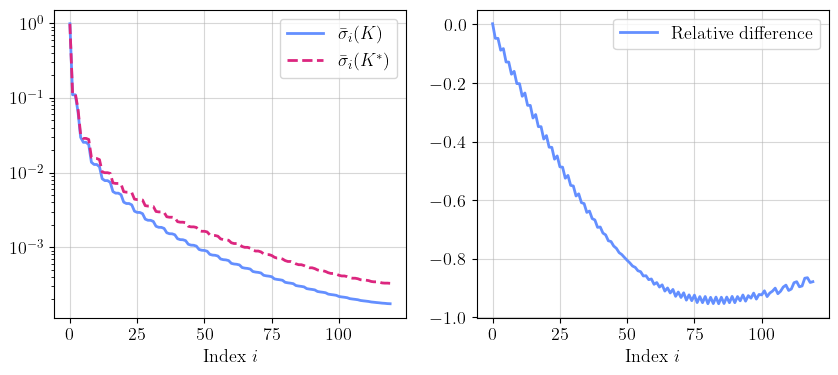

In [252]:
m = 120
g = lambda S: S / np.linalg.norm(S)

s1, s2 = g(S[:m]), g(S_tilde[:m])
ns = np.arange(m)

from utils.colors import C2
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax, ax2 = axes
ax.semilogy(ns, s1, label='$\\bar \sigma_i(K)$', c=C2[0], lw=2)
ax.semilogy(ns, s2, label='$\\bar \sigma_i(K^*)$', ls='--', c=C2[1], lw=2)

ax2.plot((s1 - s2) / s1, label='Relative difference', c=C2[0], lw=2)

for ax in axes:
    ax.grid(True, alpha=.5)
    ax.legend()
    ax.set_xlabel('Index $i$')

plt.show()


In [ ]:
@disk_cache('../../results/recover_K_exact')
def experiment(k_range, pid):
    pb = PROBLEMS[pid]
    exact = ExactForwardOperator(V_h=pb['V_h'], assemble_on_init=False)

    K = exact.assemble_K()
    K_star = exact.assemble_K_star()
    M, M_partial = csc_matrix(exact.M_dx), csc_matrix(exact.M_ds)

    # SVD of K and K*
    U, S, Vt = np.linalg.svd(K, full_matrices=False)
    U_tilde, S_tilde, Vt_tilde = np.linalg.svd(K_star, full_matrices=False)

    record = []
    n_steps, step = len(k_range), 1
    for k in k_range:
        progress_bar(step, n_steps)
        step += 1

        # Solve with exact K
        Uk, Sk, Vkt = U[:, :k], S[:k], Vt[:k, :]
        w = weights(Vt=Vkt, M=M)
        x_hat = fast_svd_solver(pb['y'], Uk, Sk, Vkt.T, M_partial, M, w, lam=1e-4)

        # Solve with recovered K
        Uk_tilde, Sk_tilde, Vkt_tilde = U_tilde[:, :k], S_tilde[:k], Vt_tilde[:k, :]
        Uk_r, Sk_r, Vkt_r = recover_K(Uk_tilde, Sk_tilde, Vkt_tilde, M, M_partial)
        w = weights(Vt=Vkt_r, M=M)
        x_hat_r = fast_svd_solver(pb['y'], Uk_r, Sk_r, Vkt_r.T, M_partial, M, w, lam=1e-4)

        result = {'k': k}
        result.update(error3(pb['x'], x_hat))
        result.update({k + '_r': v for k, v in error3(pb['x'], x_hat_r).items()})
        record.append(result)
    
    return pd.DataFrame(record)

In [128]:
k_range = np.arange(10, 100)

params = [
    {'k_range': k_range, 'pid': 'I'},
    {'k_range': k_range, 'pid': 'II'},
    {'k_range': k_range, 'pid': 'III'},
]

results = [{'params': p, 'df': experiment(**p)} for p in params]

[##############################] 90/90
[##############################] 90/90
[##############################] 90/90


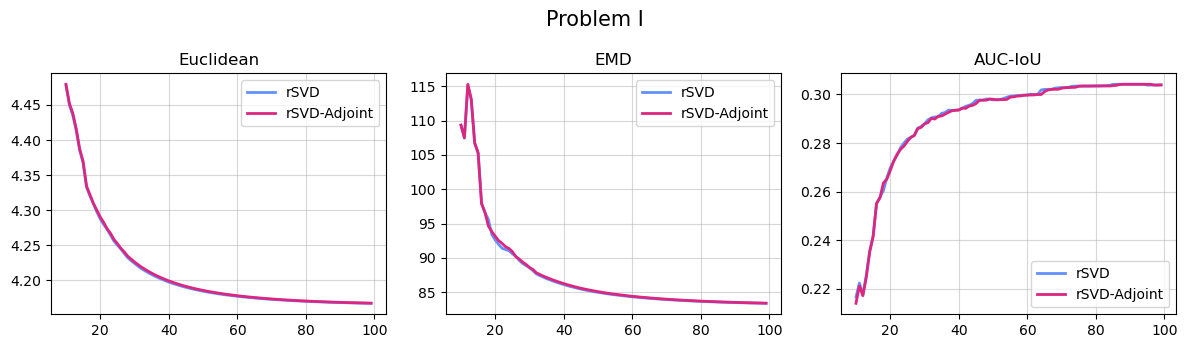

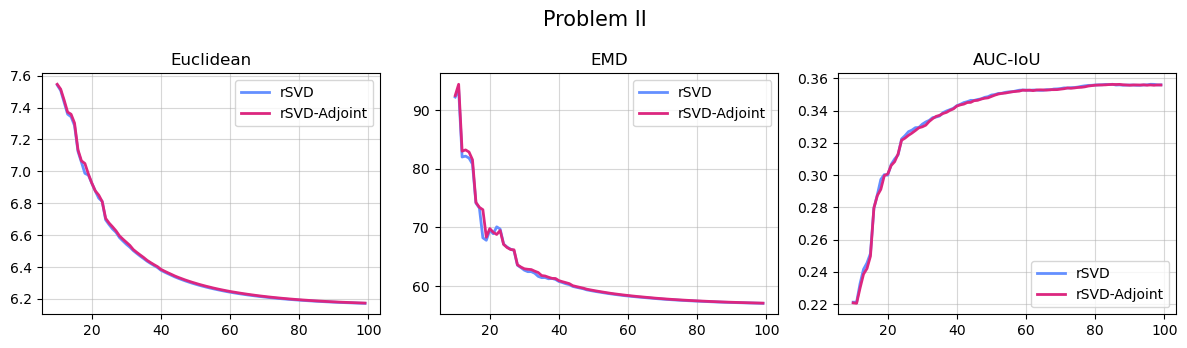

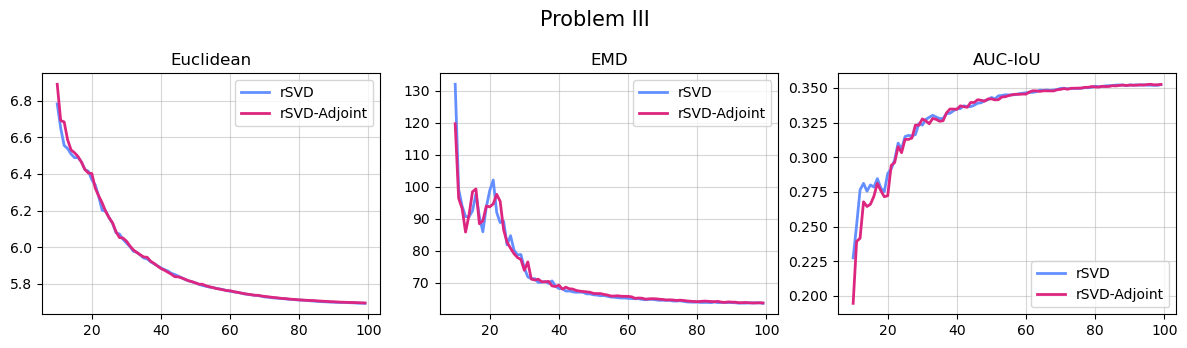

In [143]:
def plot_df(df, suptitle=None):   
    from utils.colors import C2

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    dists = ['euclidean', 'emd', 'auc_iou']
    labels = ['Euclidean', 'EMD', 'AUC-IoU']
    for i, (dist, ax) in enumerate(zip(dists, axes.flat)):
        ax.set_title(labels[i])
        ax.plot(df.k, df[dist], label='rSVD', c=C2[0], lw=2)
        #ax.axhline(1.0, c='black', ls='--')
        ax.plot(df.k, df[dist + '_r'], label='rSVD-Adjoint', c=C2[1], lw=2)

        ax.grid(True, alpha=0.5)
        ax.legend()

    plt.suptitle(suptitle, fontsize=15)
    plt.tight_layout()
    plt.show()

for r in results:
    plot_df(r['df'], suptitle='Problem ' + r['params']['pid'])

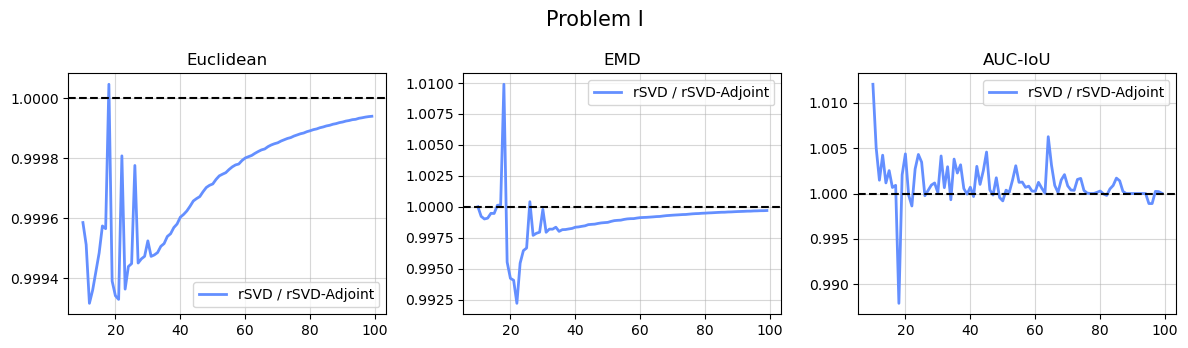

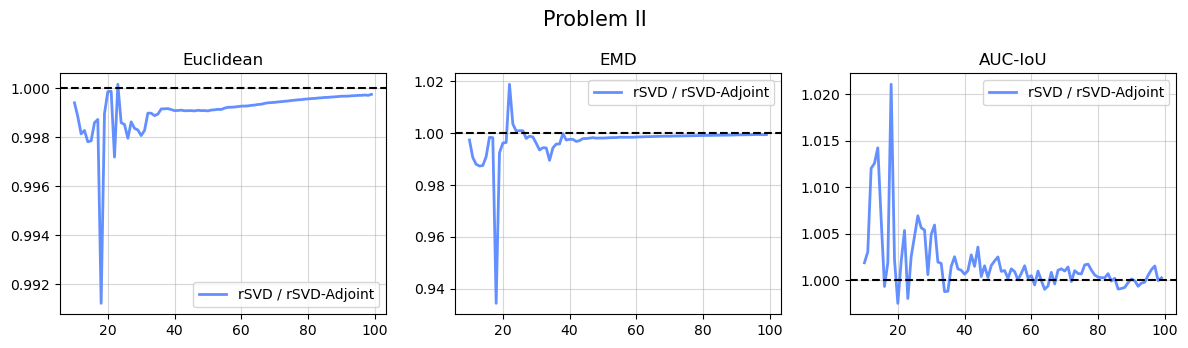

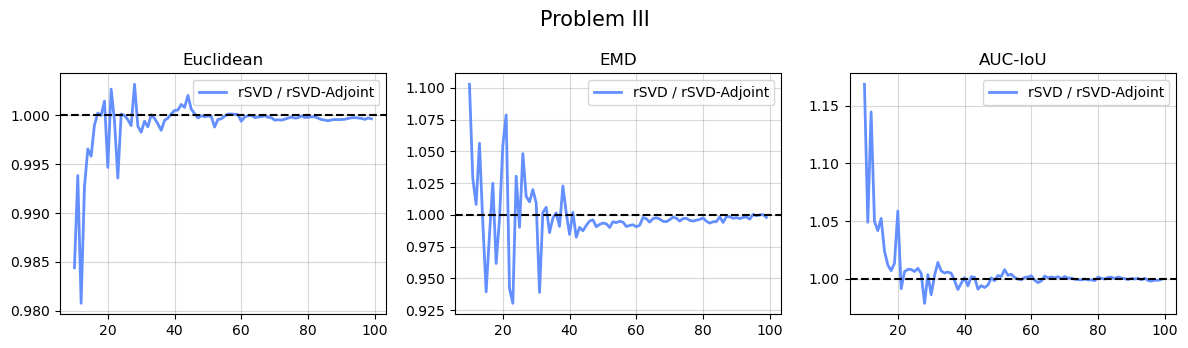

In [146]:
def plot_df_relative(df, suptitle=None):   
    from utils.colors import C2

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    dists = ['euclidean', 'emd', 'auc_iou']
    labels = ['Euclidean', 'EMD', 'AUC-IoU']
    for i, (dist, ax) in enumerate(zip(dists, axes.flat)):
        ax.set_title(labels[i])
        ax.plot(df.k, df[dist] / df[dist + '_r'], label='rSVD / rSVD-Adjoint', c=C2[0], lw=2)
        ax.axhline(1.0, c='black', ls='--')

        ax.grid(True, alpha=0.5)
        ax.legend()

    plt.suptitle(suptitle, fontsize=15)
    plt.tight_layout()
    plt.show()

for r in results:
    plot_df_relative(r['df'], suptitle='Problem ' + r['params']['pid'])